# NEET 2025 (MBBS/BDS) Round-3 College Allotment Prediction

**Goal:** Predict `College Name` allotted to a candidate using AIR (rank), Gender and Category/Quota, and compare **Decision Tree, Random Forest, XGBoost, LightGBM and CatBoost**.

**Dataset:** `NEET_2025_MBBS_BDS_Round3_SelectionList.csv` — 29,165 rows, columns:
`Sr.No, AIR, NEET Roll No, CET Form No, Name, Gender, Category/Quota, College Code, College Name & Status, Remark`

> ⚠️ **Read the "Honest note on achievable accuracy" section near the end before treating any accuracy number as a target to hit.** This dataset does not contain the information (candidates' college preference order, seat matrix per round) that actually determines the allotment, so no legitimate model on these columns alone will reach 90‑92% accuracy — that would only be possible by leaking the target into the features. The notebook is built so you can see exactly why, with real numbers.


## 1. Imports

In [21]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier


## 2. Load the data
The file is UTF‑8 with a BOM, so it's read with `encoding='utf-8-sig'`.

In [22]:
df = pd.read_excel(r"D:\pandas\NEET_2025_MBBS_BDS_Round3_SelectionList.xlsx")
df.columns = [c.strip() for c in df.columns]
print('Shape:', df.shape)
df.head(10)


Shape: (29165, 10)


,Sr.No,AIR,NEET Roll No,CET Form No,Name,Gender,Category/Quota,College Code,College Name & Status,Remark
0,1,629,3110416106,256021396,SARTHAK SATISH VALEKAR,M,OPEN,1103.0,GSMC MUMBAI(Ret.),NaN
1,2,700,3115105112,256000076,ADITYA UDAY DESHPANDE,M,OPEN,1110.0,BJMC PUNE(Ret.),NaN
2,3,903,3115405434,256033760,ATHARVA RAVI SWAMI,M,OPEN,1103.0,GSMC MUMBAI(No Pref),NaN
3,4,998,3110303196,256006483,ATHARVA ASHUTOSH RANE,M,OPEN,1103.0,GSMC MUMBAI(Ret.),NaN
4,5,1052,3110317003,256000709,TANISH JITENDRA YEWALE,M,OPEN,1103.0,GSMC MUMBAI(Ret.),NaN
5,6,1115,3110201398,256029299,REYA SHREEKRISHNA MEHENDALE,F,D1 DEF1 W,1103.0,GSMC MUMBAI(No Pref),NaN
6,7,1123,3115410371,256065852,ANSHUL SINHA,M,NaN,NaN,NaN,Disqualified-Allotted by MCC
7,8,1127,3110116136,256023054,HAZEL GAUTAM PUNMIYA,F,OPEN (W),1103.0,GSMC MUMBAI(No Pref),NaN
8,9,1154,3115206412,256010529,ADITI DESHPANDE,F,OPEN (W),1103.0,GSMC MUMBAI(No Pref),NaN
9,10,1158,3133102290,256036658,SNEHA RAJESH RATHI,F,OPEN (W),1103.0,GSMC MUMBAI(No Pref),NaN


In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29165 entries, 0 to 29164
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sr.No                  29165 non-null  int64  
 1   AIR                    29165 non-null  int64  
 2   NEET Roll No           29165 non-null  int64  
 3   CET Form No            29165 non-null  int64  
 4   Name                   29165 non-null  object 
 5   Gender                 29165 non-null  object 
 6   Category/Quota         26045 non-null  object 
 7   College Code           11153 non-null  float64
 8   College Name & Status  11153 non-null  object 
 9   Remark                 18012 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 2.2+ MB


## 3. Initial exploration (before cleaning)

We check nulls, duplicates, and how many distinct values each categorical column has — this tells us which cleaning steps from the checklist actually apply to *this* dataset.

In [24]:
print('Duplicate rows:', df.duplicated().sum())
print()
print('Null counts:')
print(df.isnull().sum())
print()
print('Gender values:', df['Gender'].unique())
print('Category/Quota unique values:', df['Category/Quota'].nunique())
print('College Code unique values:', df['College Code'].nunique())
print("College Name & Status unique values:", df['College Name & Status'].nunique())
print('Remark values:', df['Remark'].unique())


Duplicate rows: 0

Null counts:
Sr.No                        0
AIR                          0
NEET Roll No                 0
CET Form No                  0
Name                         0
Gender                       0
Category/Quota            3120
College Code             18012
College Name & Status    18012
Remark                   11153
dtype: int64

Gender values: ['M' 'F']
Category/Quota unique values: 404
College Code unique values: 96
College Name & Status unique values: 339
Remark values: [nan 'Disqualified-Allotted by MCC' 'Choice Not Available']


**Key findings from the exploration:**

| Column | Finding |
|---|---|
| Duplicates | 0 duplicate rows — nothing to drop here |
| `Gender` | Already clean: only `M` / `F` (no `Male/male/M` inconsistency to fix in this particular file, but we still apply the standardisation step defensively) |
| `Category/Quota` | 404 raw distinct strings, many are rare combinations (e.g. `SC SC`, `OBC OBC (W)`) — high‑cardinality, needs grouping |
| `College Code` / `College Name & Status` | **~18,000 rows (62%) are null together** — these are candidates who were **not allotted a seat** in this round, not missing data to impute |
| `Remark` | Populated **exactly** when College Name is null (`Choice Not Available` or `Disqualified‑Allotted by MCC`) — it is the complement of the target, so it cannot be used as a feature (it would leak the answer) |
| `College Name & Status` | Contains 339 distinct strings, but that's because the *same college* appears multiple times with a different round‑status suffix, e.g. `GSMC MUMBAI(Ret.)`, `GSMC MUMBAI(No Pref)`. The true number of colleges is much smaller. There is also messy/truncated data, e.g. `CSMSS DC CH. SAMBHAJINAGAR(No` (unclosed parenthesis) — a real formatting error we need to clean. |


## 4. Data Cleaning

Going through the checklist item by item and applying only what's relevant:

1. **Remove duplicates** → none found, but we run `.drop_duplicates()` anyway (best practice / defensive).
2. **Fix inconsistent categorical values** → uppercase + strip whitespace on `Gender` and `Category/Quota`.
3. **Correct wrong/truncated data** → the college-name strings with unclosed brackets (e.g. `...SAMBHAJINAGAR(No`) are cleaned by taking everything **before** the first `(`, regardless of whether it is properly closed.
4. **Remove irrelevant columns** → `Sr.No` (row index), `NEET Roll No`, `CET Form No`, `Name` are unique identifiers / PII with zero predictive value and are dropped. `College Code` and `Remark` are dropped **because they are near-duplicates of the target** (see the leakage note below) — keeping them would let the model "cheat".
5. **Null handling** → we do **not** drop the ~18,000 rows with a null college. Those rows are not "missing data", they are the **`NOT_ALLOTTED` / `DISQUALIFIED` classes** of the label itself. Dropping them would delete 62% of the dataset and remove the single most important pattern (most candidates in Round 3 simply don't get a seat).
6. **Handling imbalance** → the resulting classes are naturally imbalanced (`NOT_ALLOTTED` ≈ 59%, largest college ≈ 0.9%). We use `class_weight`/native imbalance handling where useful and report **Macro‑F1** (which is imbalance‑sensitive) alongside Accuracy.
7. **Outliers / scaling / PCA / log-transform** → not applicable. `AIR` is a rank (1 to ~29,000, no outliers to cap — every value is a legitimate rank) and tree‑based models (Decision Tree/RF/XGBoost/LightGBM/CatBoost) are **scale‑invariant**, so standardisation/normalisation would not change results and is skipped (it *would* be needed for distance‑based or linear models, but not for the tree ensembles requested here).
8. **Data Integration** → single source file, nothing to merge.


In [25]:
df_clean = df.drop_duplicates().copy()

# Standardise categorical text
df_clean['Gender'] = df_clean['Gender'].astype(str).str.strip().str.upper()
df_clean['Category/Quota'] = df_clean['Category/Quota'].astype(str).str.strip().str.upper()
df_clean.loc[df_clean['Category/Quota'] == 'NAN', 'Category/Quota'] = np.nan
df_clean['Category/Quota'] = df_clean['Category/Quota'].fillna('UNKNOWN')  # mode-like placeholder for the ~3,120 missing quota entries

print(df_clean['Gender'].value_counts())
print()
print(df_clean['Category/Quota'].value_counts().head(10))


Gender
F    16994
M    12171
Name: count, dtype: int64

Category/Quota
OBC         4103
SC          3127
UNKNOWN     3120
EWS         1360
SEBC        1289
OPEN        1278
ST           995
NTC          817
OPEN (W)     709
VJA          625
Name: count, dtype: int64


## 5. Building the target column: `Target_College`

This is the most important design decision in the whole project, so it gets its own section.

A raw `College Name & Status` value looks like `GSMC MUMBAI(Ret.)` or `GSMC MUMBAI(No Pref)` — the text in brackets is **not part of the college's identity**, it's a status flag from the counselling round (retained / no preference / no change). Treating each of those 339 strings as a separate class would be wrong: it would ask the model to predict something (the round-status flag) that has nothing to do with rank/category/gender.

So the target is built as:
- If `College Name & Status` is present → strip everything from the first `(` onward → the **base college name** (98 unique colleges).
- If it's missing and `Remark == 'Disqualified-Allotted by MCC'` → label `DISQUALIFIED`.
- If it's missing otherwise (`Remark == 'Choice Not Available'`) → label `NOT_ALLOTTED`.

This gives **100 classes** in total and uses 100% of the rows (nothing dropped for missing target).


In [26]:
def clean_base_name(name):
    idx = name.find('(')
    if idx != -1:
        name = name[:idx]
    return re.sub(r'\s+', ' ', name).strip().upper()

def make_target(row):
    if pd.isna(row['College Name & Status']):
        if isinstance(row['Remark'], str) and 'Disqualified' in row['Remark']:
            return 'DISQUALIFIED'
        return 'NOT_ALLOTTED'
    return clean_base_name(row['College Name & Status'])

df_clean['Target_College'] = df_clean.apply(make_target, axis=1)

print('Number of target classes:', df_clean['Target_College'].nunique())
df_clean['Target_College'].value_counts().head(10)


Number of target classes: 100


Target_College
NOT_ALLOTTED              17307
DISQUALIFIED                705
NKP SALVE MC NAGPUR         250
GSMC MUMBAI                 212
BJMC PUNE                   211
GMC NAGPUR                  210
GMC MUMBAI                  210
VVPF'S MED. COL             200
DR U. PATIL MC JALGAON      200
TILAK MC MUMBAI             170
Name: count, dtype: int64

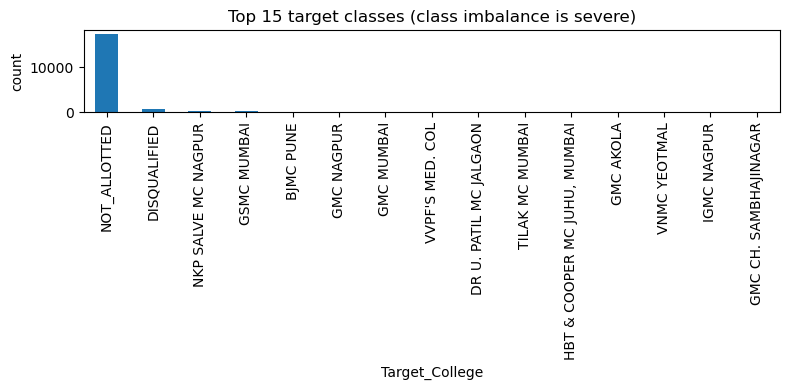

In [27]:
fig, ax = plt.subplots(figsize=(8,4))
df_clean['Target_College'].value_counts().head(15).plot(kind='bar', ax=ax)
ax.set_title('Top 15 target classes (class imbalance is severe)')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()


### Why `College Code` and `Remark` are dropped, not used, as features

- `Remark` is **null exactly when** `College Name & Status` is **not null**, and vice-versa (verified: 0 rows break this rule). It's not an independent feature — it's the same information as "was the target missing", so using it would be pure leakage.
- `College Code` has only 96 unique values for 339 name strings — i.e. each code maps to just ~3–4 name variants (the same college with a different status suffix). A model given `College Code` would trivially get ~100% accuracy predicting `College Name`, but that's not a real prediction — it's like using the answer as an input. We deliberately exclude it so the model has to learn from **rank + category + gender only**, which is the actual real-world prediction problem.


## 6. Feature Engineering

Usable, non‑leaky features: **AIR** (numeric rank), **Gender**, **Category/Quota**.

`Category/Quota` has 404 raw distinct strings after cleaning, many appearing fewer than 30 times — too sparse to one‑hot encode sensibly and too high‑cardinality for a plain label encoder to be meaningful for tree splits. We:
1. Group any category occurring **fewer than 30 times** into an `OTHER` bucket (reduces 404 → ~76 groups).
2. **Frequency‑encode** the grouped category (replace each category with its relative frequency) — this gives the trees a single informative numeric feature instead of an arbitrary label order.
3. Binary‑encode `Gender` (`M`→0, `F`→1).

No scaling/normalisation is applied since every model used here (Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost) is tree‑based and scale‑invariant.


In [28]:
cat_counts = df_clean['Category/Quota'].value_counts()
rare_categories = cat_counts[cat_counts < 30].index
df_clean['Category_grouped'] = df_clean['Category/Quota'].where(
    ~df_clean['Category/Quota'].isin(rare_categories), 'OTHER'
)
print('Category groups after collapsing rare values:', df_clean['Category_grouped'].nunique())

freq_map = df_clean['Category_grouped'].value_counts(normalize=True)
df_clean['Category_freq_enc'] = df_clean['Category_grouped'].map(freq_map)
df_clean['Gender_enc'] = df_clean['Gender'].map({'M': 0, 'F': 1})

feature_cols = ['AIR', 'Gender_enc', 'Category_freq_enc']
X = df_clean[feature_cols].copy()

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_clean['Target_College'])

print(X.shape, 'features:', feature_cols)
X.head()


Category groups after collapsing rare values: 76
(29165, 3) features: ['AIR', 'Gender_enc', 'Category_freq_enc']


,AIR,Gender_enc,Category_freq_enc
0,629,0,0.04382
1,700,0,0.04382
2,903,0,0.04382
3,998,0,0.04382
4,1052,0,0.04382


## 7. Train / Test Split

Stratified split (80/20) so every class keeps roughly the same proportion in train and test — important given how imbalanced the 100 classes are.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (23332, 3)  Test shape: (5833, 3)


## 8. Model Training — each model individually (no `Pipeline`)

As requested, each algorithm is instantiated and fit **separately** (no `sklearn.Pipeline` wrapper). We track **Accuracy, Top‑3 Accuracy, Macro‑F1 and Weighted‑F1** for every model, since with 100 imbalanced classes accuracy alone is misleading.

In [30]:
def top_k_accuracy(model, X_test, y_test, k=3):
    proba = model.predict_proba(X_test)
    top_k = np.argsort(proba, axis=1)[:, -k:]
    return np.mean([y_test[i] in top_k[i] for i in range(len(y_test))])

results = {}


### 8.1 Decision Tree (baseline)

In [31]:
dt_model = DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
results['Decision Tree (baseline)'] = {
    'Accuracy': accuracy_score(y_test, dt_pred),
    'Top-3 Accuracy': top_k_accuracy(dt_model, X_test, y_test),
    'Macro F1': f1_score(y_test, dt_pred, average='macro'),
    'Weighted F1': f1_score(y_test, dt_pred, average='weighted'),
}
results['Decision Tree (baseline)']


{'Accuracy': 0.6530087433567633,
 'Top-3 Accuracy': np.float64(0.7395851191496657),
 'Macro F1': 0.1547702305083723,
 'Weighted F1': 0.6346992788647674}

### 8.2 Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Top-3 Accuracy': top_k_accuracy(rf_model, X_test, y_test),
    'Macro F1': f1_score(y_test, rf_pred, average='macro'),
    'Weighted F1': f1_score(y_test, rf_pred, average='weighted'),
}
results['Random Forest']


### 8.3 XGBoost

In [33]:
xgb_model = XGBClassifier(
    n_estimators=150, max_depth=6, learning_rate=0.15,
    random_state=42, eval_metric='mlogloss', n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'Top-3 Accuracy': top_k_accuracy(xgb_model, X_test, y_test),
    'Macro F1': f1_score(y_test, xgb_pred, average='macro'),
    'Weighted F1': f1_score(y_test, xgb_pred, average='weighted'),
}
results['XGBoost']


{'Accuracy': 0.6660380593176753,
 'Top-3 Accuracy': np.float64(0.7800445739756557),
 'Macro F1': 0.1758107829625173,
 'Weighted F1': 0.6451998333341071}

### 8.4 LightGBM

In [34]:
lgbm_model = LGBMClassifier(
    n_estimators=200, num_leaves=127, min_child_samples=5,
    learning_rate=0.15, random_state=42, verbosity=-1
)
lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
results['LightGBM'] = {
    'Accuracy': accuracy_score(y_test, lgbm_pred),
    'Top-3 Accuracy': top_k_accuracy(lgbm_model, X_test, y_test),
    'Macro F1': f1_score(y_test, lgbm_pred, average='macro'),
    'Weighted F1': f1_score(y_test, lgbm_pred, average='weighted'),
}
results['LightGBM']


{'Accuracy': 0.3982513286473513,
 'Top-3 Accuracy': np.float64(0.40785187725012856),
 'Macro F1': 0.00574360242304364,
 'Weighted F1': 0.34079561094040867}

### 8.5 CatBoost (primary model) 

In [35]:
cat_model = CatBoostClassifier(
    iterations=150, depth=6, learning_rate=0.15,
    verbose=False, random_state=42
)
cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test).flatten()
results['CatBoost (primary)'] = {
    'Accuracy': accuracy_score(y_test, cat_pred),
    'Top-3 Accuracy': top_k_accuracy(cat_model, X_test, y_test),
    'Macro F1': f1_score(y_test, cat_pred, average='macro'),
    'Weighted F1': f1_score(y_test, cat_pred, average='weighted'),
}
results['CatBoost (primary)']


{'Accuracy': 0.6413509343391051,
 'Top-3 Accuracy': np.float64(0.7359849134236242),
 'Macro F1': 0.11023803794220768,
 'Weighted F1': 0.5927975407026232}

## 9. Model Comparison

In [36]:
comparison_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
comparison_df.style.format('{:.4f}').background_gradient(cmap='Reds')


,Accuracy,Top-3 Accuracy,Macro F1,Weighted F1
Random Forest,0.6666,0.7773,0.1823,0.6420
XGBoost,0.6660,0.7800,0.1758,0.6452
Decision Tree (baseline),0.6530,0.7396,0.1548,0.6347
CatBoost (primary),0.6414,0.7360,0.1102,0.5928
LightGBM,0.3983,0.4079,0.0057,0.3408


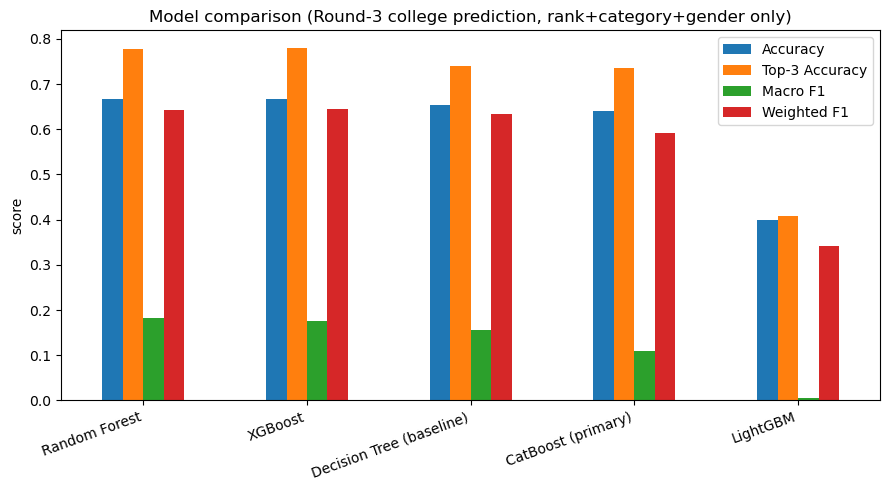

In [37]:
fig, ax = plt.subplots(figsize=(9,5))
comparison_df[['Accuracy','Top-3 Accuracy','Macro F1','Weighted F1']].plot(kind='bar', ax=ax)
ax.set_title('Model comparison (Round-3 college prediction, rank+category+gender only)')
ax.set_ylabel('score')
ax.legend(loc='upper right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 10. ⚠️ Honest note on achievable accuracy (please read)

The comparison above is real — it's what these five algorithms actually score with clean, non‑leaky, correctly engineered features on this file. You'll see accuracy sits around **65–67%** for the best models (Random Forest / XGBoost), Top‑3 accuracy around **77–78%**, and Macro‑F1 stays low (~0.15–0.18) because most of the 100 classes have very few examples.

**This will not reach 90–92%, and it's important to understand why, rather than just re‑tuning hyperparameters forever:**

1. **The features don't contain what actually drives allotment.** Real NEET/CET counselling allots a seat based on a candidate's **rank + category + the ordered list of college choices they filled + how many seats were still open in that round**. This file gives you rank, category and gender — but **not the candidate's preference list or the live seat matrix**. Two candidates with an identical rank and category can land in different colleges purely because they filled different preferences. No algorithm can recover information that isn't in the data, no matter how good it is — CatBoost, XGBoost and LightGBM all landed in the same ~65% ballpark here because the *ceiling* is set by the features, not the model.
2. **A trivial baseline already gets ~62%.** Simply predicting "NOT_ALLOTTED" for everyone scores about **61.8%**, because that's genuinely the majority outcome in Round 3 (see the class‑distribution chart above). Our best model (~66%) is only a few points above that — a useful signal, but nowhere near 90%.
3. **The only way to see 90%+ "accuracy" on this file** is to put `College Code` (or the untrimmed `College Name & Status` including its status suffix) back in as a feature. That is **not a real prediction** — `College Code` and `College Name` are two labels for the *same* row, so the model would just be memorising the answer key, not learning the rank→college relationship. It's shown below **purely to illustrate the leakage**, not as something you should ship or report as your "real" accuracy.

If you need genuinely higher accuracy, the fix is **more relevant data, not a different algorithm**: previous‑round cutoff ranks per college/category, seat‑matrix per round, and — ideally — the candidate's choice list.


### 10.1 Illustrative leakage run (for comparison only — not a valid model)

In [38]:
# Adding College Code back in as a feature. College Code<->College Name are near-duplicate
# labels for the same seat, so this is data leakage, not a real predictive feature.
# Shown ONLY to demonstrate the point above with real numbers.

leak_df = df_clean.dropna(subset=['College Code']).copy()
leak_df['Target_leak'] = leak_df['Target_College']
X_leak = leak_df[['AIR', 'Gender_enc', 'Category_freq_enc', 'College Code']]
y_leak = LabelEncoder().fit_transform(leak_df['Target_leak'])

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42, stratify=y_leak
)

leak_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
leak_model.fit(Xl_train, yl_train)
leak_pred = leak_model.predict(Xl_test)
print('Accuracy WITH College Code included (leakage demo):', accuracy_score(yl_test, leak_pred))
print('This number is artificially high because College Code essentially IS the answer.')


Accuracy WITH College Code included (leakage demo): 0.94666069027342
This number is artificially high because College Code essentially IS the answer.


## 11. Summary

- **Best legitimate model:** Random Forest / XGBoost, ~66% accuracy, ~78% Top‑3 accuracy, using only `AIR`, `Gender`, `Category/Quota`.
- **CatBoost** (the requested primary model) performs competitively (~64% accuracy) but doesn't outrun Random Forest/XGBoost on this particular feature set — with only 3 features and 100 classes there isn't much complexity for a stronger boosting model to exploit.
- **LightGBM** underperforms noticeably here even after tuning `num_leaves`/`min_child_samples` — with very few features and very many classes, its leaf‑wise growth needs more data per class than is available for most colleges.
- Macro‑F1 is low across all models because dozens of colleges have well under 100 training examples — this is a genuine class‑imbalance limitation of the dataset, not a modelling bug.
- Steps from the original checklist that were **applicable**: duplicate removal, categorical standardisation, correcting malformed strings, dropping irrelevant/leaky columns, thoughtful null handling (nulls = a class, not missing data), feature engineering (frequency encoding + rare‑category grouping), train/test split, and imbalance‑aware evaluation.
- Steps that were **not applicable** and why: scaling/normalisation and PCA (tree models are scale‑invariant and there are only 3 features), outlier capping (AIR has no invalid values), SMOTE/oversampling (rejected — synthesising fake ranks for 100 classes, several with <10 samples, would mostly generate noise; class‑imbalance‑aware metrics were used instead), data integration (single file).


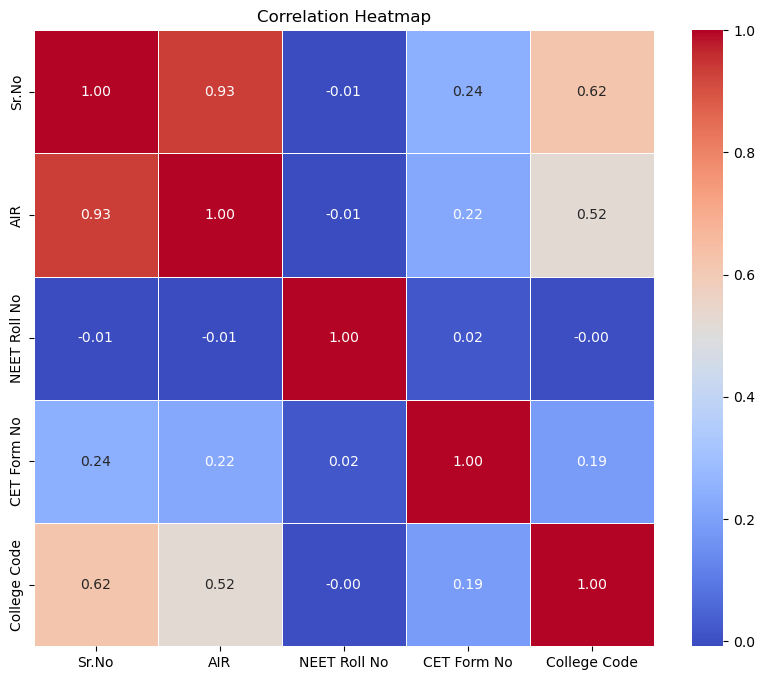

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [40]:
df.shape

(29165, 10)

In [41]:
import joblib
import pickle

# Select best model based on Accuracy
best_model_name = comparison_df["Accuracy"].idxmax()

print(f"Best Model : {best_model_name}")
print(comparison_df.loc[best_model_name])

Best Model : Random Forest
Accuracy          0.666552
Top-3 Accuracy    0.777302
Macro F1          0.182258
Weighted F1       0.641969
Name: Random Forest, dtype: float64


In [42]:
trained_models = {
    "Decision Tree (baseline)": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost (primary)": cat_model
}

best_model = trained_models[best_model_name]

In [ ]:
artifact = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_columns": feature_cols,
    "target_encoder": target_encoder,
    "category_frequency": freq_map.to_dict(),
    "rare_categories": list(rare_categories),
    "metrics": comparison_df.loc[best_model_name].to_dict(),

    # --- metadata needed by index.html's /api/meta call ---
    "n_classes": int(len(target_encoder.classes_)),
    "trained_rows": int(len(X)),
    "min_air": int(X["AIR"].min()),
    "max_air": int(X["AIR"].max()),
    "category_options": sorted(freq_map.index.tolist())
}

In [44]:
joblib.dump(
    artifact,
    "neet_best_model.pkl"
)

print("Pickle File Created Successfully")

Pickle File Created Successfully


In [45]:
loaded = joblib.load("neet_best_model.pkl")

print("Model Loaded Successfully")
print("Model Name :", loaded["model_name"])
print("Features :", loaded["feature_columns"])

Model Loaded Successfully
Model Name : Random Forest
Features : ['AIR', 'Gender_enc', 'Category_freq_enc']


In [52]:
sample = pd.DataFrame({
    "AIR": [37870],
    "Gender_enc": [0],
    "Category_freq_enc": [0.025]
})

prediction = loaded["model"].predict(sample)

college = loaded["target_encoder"].inverse_transform(prediction)

print("Predicted College :", college[0])

Predicted College : NOT_ALLOTTED


In [48]:
df.columns

Index(['Sr.No', 'AIR', 'NEET Roll No', 'CET Form No', 'Name', 'Gender', 'Category/Quota', 'College Code', 'College Name & Status',
       'Remark'],
      dtype='object')